# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [22]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

***
## 2. Load data

In [24]:
df = pd.read_csv('../resources/data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


***
## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [25]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [26]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [28]:
# Add model training in here!
model = RandomForestClassifier(random_state=42) # Add parameters to the model!
model.fit(X=X_train, y=y_train) # Complete this method call!

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [29]:
# Generate predictions here!
y_pred = model.predict(X=X_test)

In [30]:
# Calculate performance metrics here!
model.score(X_test, y_test)

0.9030668127053669

## Metrics

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

We would like our model to be as precise as possible, thinking that if we can predict what clients can churn, it is possible to contact them with a better offer to maintain that client.  
+ The true positives (TP) for churn=1, will give the clients to contact with a better offer.  
+ The false positives (FP) for churn=1 are clients that may not think to churn, but offering them a better offer is not a bas outcome.  
+ The false negatives (FN) for churn=1 are those clients that will churn and we could not predict, therefore, the company will lose a client.  

The ideal model should have a low number of FN, and additionally low number of FP, so the ratio Recall = (TP /(TP + FN)) should be as close as 1 as we can.



In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.71      0.05      0.10       366

    accuracy                           0.90      3652
   macro avg       0.81      0.53      0.53      3652
weighted avg       0.89      0.90      0.86      3652



Confusion Matrix

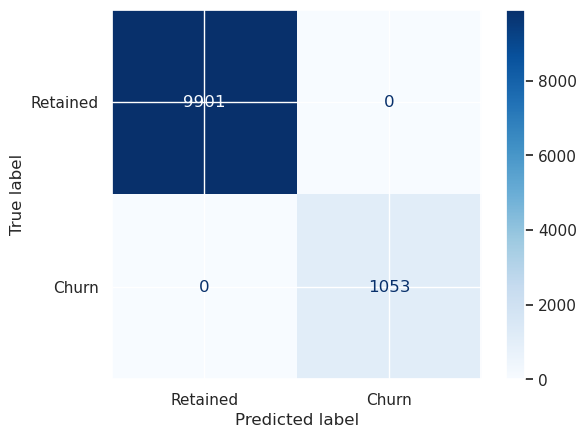

In [ ]:
confusion_matrix(y_test, y_pred)
class_names=["Retained", "Churn"]

# disp = ConfusionMatrixDisplay.from_estimator(
#         model,
#         X_test,
#         y_test,
#         display_labels=class_names,
#         cmap="Blues",
#         normalize="true",
#     )



The current model has a good precision and recall for the Retained clients, but the **recall** for the **churning clients** it is not good **(5%)**, which indicates that are many clients that churn that are predicted as retained.

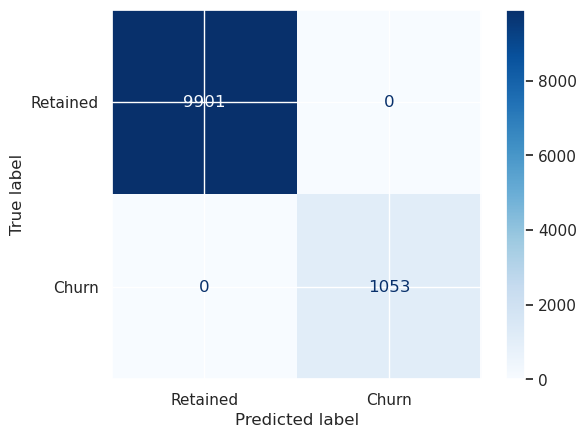

In [50]:
disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_train,
        y_train,
        display_labels=class_names,
        cmap="Blues",
        # normalize="true",
    )

Using the confusion matrix on the training dataset we can see that the model suffers from overfit

### Feature importance

In [12]:
imp_df = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": model.feature_importances_
})

imp_df.sort_values(by="Imp", ascending=False)

,Varname,Imp
0,cons_12m,0.051672
14,net_margin,0.049589
5,forecast_meter_rent_12m,0.049370
11,margin_gross_pow_ele,0.047671
12,margin_net_pow_ele,0.046966
...,...,...
54,channel_ewpakwlliwisiwduibdlfmalxowmwpci,0.002776
30,var_6m_price_mid_peak_fix,0.002225
29,var_6m_price_peak_fix,0.002123
4,forecast_discount_energy,0.001203


# Hyperparameter Tuning

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score


In [14]:
recall_for_one = make_scorer(recall_score, pos_label=1)


In [15]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {
    # 'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [1,5,10],
    'n_estimators': [10,30,50,100,200]
}


# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, verbose=1, 
                           scoring=recall_for_one)


In [16]:

%%time
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


CPU times: user 1.72 s, sys: 220 ms, total: 1.94 s
Wall time: 23.7 s


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'min_samples_leaf': [1, 5, ...], 'n_estimators': [10, 30, ...]}"
,scoring,"make_scorer(r..., pos_label=1)"
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,30


In [17]:
grid_search.best_score_

np.float64(0.05886707289550891)

In [18]:
rf_best = grid_search.best_estimator_
rf_best

,n_estimators,30
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred = rf_best.predict(X=X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.75      0.06      0.11       366

    accuracy                           0.90      3652
   macro avg       0.83      0.53      0.53      3652
weighted avg       0.89      0.90      0.86      3652



## Plot Tree

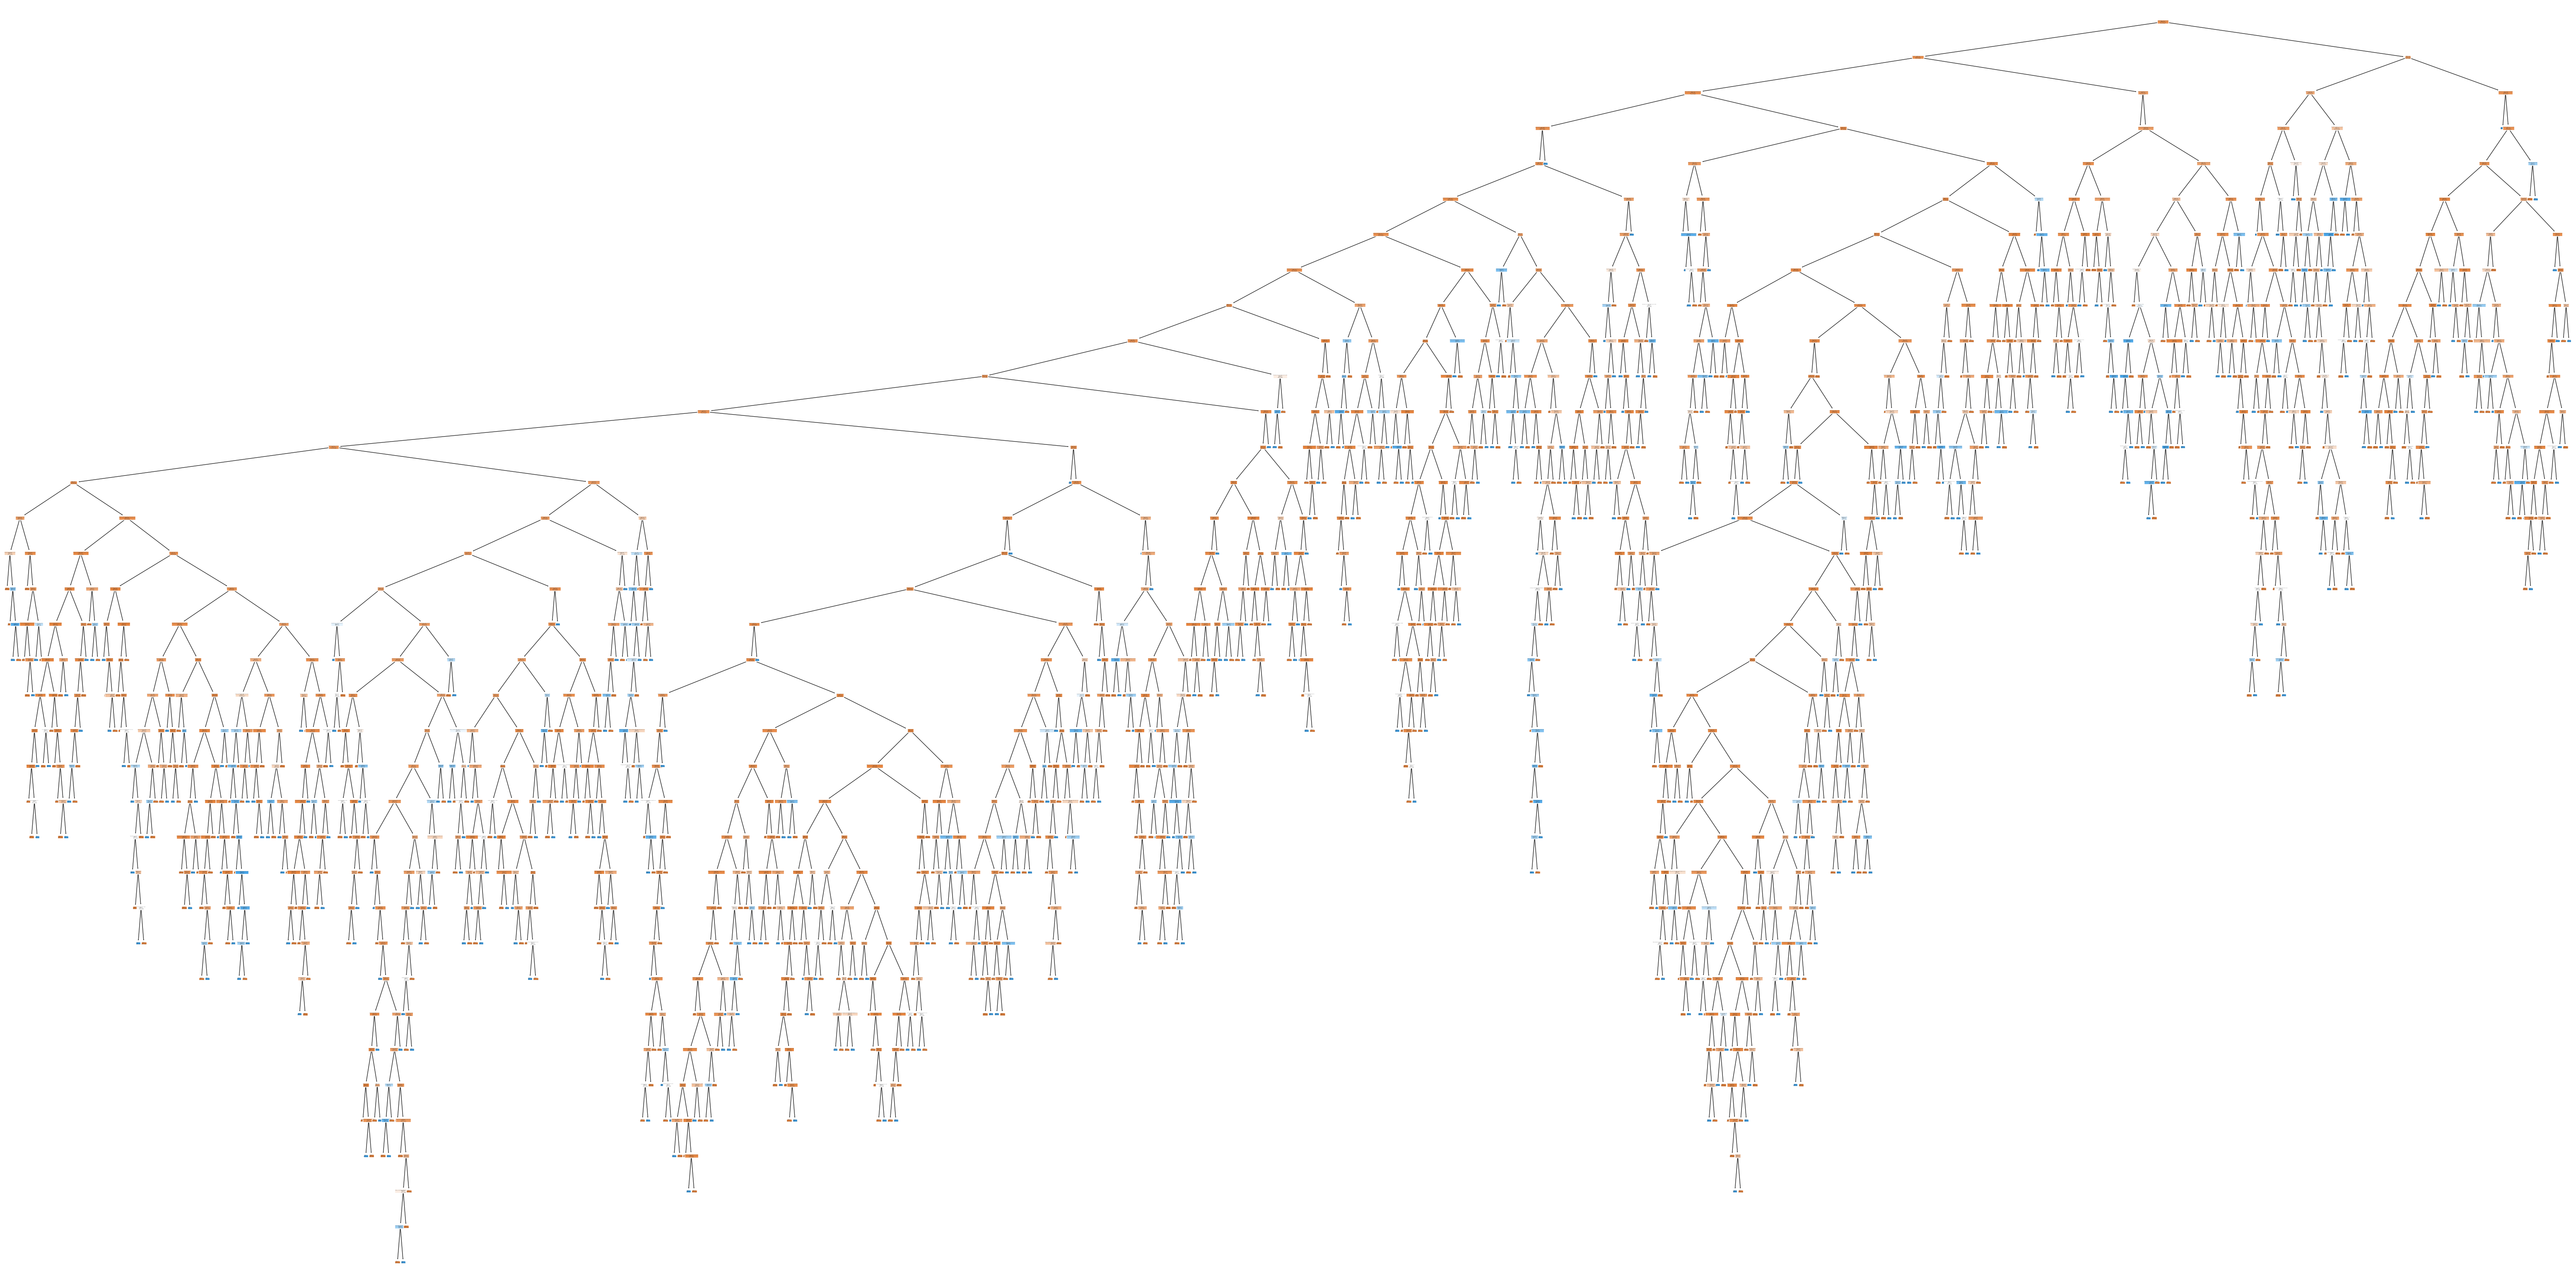

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_best.estimators_[1], feature_names = X.columns, class_names=['Retained', "Churn"],filled=True)
plt.show()

### Feature importance

In [21]:
imp_df2 = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": rf_best.feature_importances_
})

imp_df2.sort_values(by="Imp", ascending=False)

,Varname,Imp
0,cons_12m,0.052759
14,net_margin,0.049901
12,margin_net_pow_ele,0.049153
11,margin_gross_pow_ele,0.048234
5,forecast_meter_rent_12m,0.047696
...,...,...
54,channel_ewpakwlliwisiwduibdlfmalxowmwpci,0.002775
30,var_6m_price_mid_peak_fix,0.002544
29,var_6m_price_peak_fix,0.001622
4,forecast_discount_energy,0.001136


# Questions to answer:

1. Why did you choose the evaluation metrics that you used? Please elaborate on your choices.

2. Do you think that the model performance is satisfactory? Give justification for your answer.

3. Make sure that your work is presented clearly with comments and explanations